In [ ]:
import pandas as pd

baseline = pd.read_csv("baseline_mean_result.csv")
knn_rf = pd.read_csv("nguoi2_knn_rf_sklearn_result.csv")

dt_gb_results = pd.DataFrame([
    {"Model": "Decision Tree Regressor", "RMSE": 0.9291, "MAE": 0.7334},
    {"Model": "Gradient Boosting Regressor", "RMSE": 0.9079, "MAE": 0.7126},
])

baseline_std = baseline[["Model", "RMSE", "MAE"]]

summary_results = pd.concat(
    [
        baseline_std,
        knn_rf[["Model", "RMSE", "MAE"]],
        dt_gb_results
    ],
    ignore_index=True
)

summary_results

,Model,RMSE,MAE
0,Baseline Mean + User Bias + Movie Bias,0.943271,0.747727
1,KNN Regressor,1.112093,0.900910
2,Random Forest Regressor,1.066338,0.877558
3,Decision Tree Regressor,0.929100,0.733400
4,Gradient Boosting Regressor,0.907900,0.712600


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv("ratings_baseline_label_encoded.csv")

print(df.head())
print(df.columns)
X = df[["user_enc", "movie_enc"]]
y = df["rating"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X_train, y_train)

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_du_doan_knn = knn.predict(X_test)

y_du_doan_dt = dt.predict(X_test)

gia_tri_trung_binh = y_train.mean()
y_du_doan_baseline = np.full(len(y_test), gia_tri_trung_binh)

y_du_doan_voting = (
    y_du_doan_baseline +
    y_du_doan_knn +
    y_du_doan_dt
) / 3
rmse_voting = mean_squared_error(y_test, y_du_doan_voting) ** 0.5
mae_voting  = mean_absolute_error(y_test, y_du_doan_voting)

print("=== Manual Ensemble Voting Regressor ===")
print("RMSE:", rmse_voting)
print("MAE :", mae_voting)


   user_id  movie_id  rating  timestamp  user_enc  movie_enc  user_bias  \
0      196       242       3  881250949         0          0  -0.033937   
1      186       302       3  891717742         1          1  -0.046341   
2       22       377       1  878887116         2          2  -0.124008   
3      244        51       2  880606923         3          3   0.122386   
4      166       346       1  886397596         4          4   0.146212   

   movie_bias  global_mean  baseline_pred  
0    0.544340     3.531887       4.042291  
1    0.725679     3.531887       4.211226  
2   -0.502237     3.531887       2.905642  
3    0.069842     3.531887       3.724115  
4    0.184331     3.531887       3.862431  
Index(['user_id', 'movie_id', 'rating', 'timestamp', 'user_enc', 'movie_enc',
       'user_bias', 'movie_bias', 'global_mean', 'baseline_pred'],
      dtype='object')
=== Manual Ensemble Voting Regressor ===
RMSE: 1.0879495612965109
MAE : 0.899572502566412


In [4]:
import pandas as pd

ket_qua_cac_mo_hinh = pd.DataFrame([
    {"Model": "Global Mean Baseline", "RMSE": 0.9433, "MAE": 0.7477},
    {"Model": "KNN Regressor", "RMSE": 1.1121, "MAE": 0.9009},
    {"Model": "Random Forest Regressor", "RMSE": 1.0663, "MAE": 0.8776},
    {"Model": "Decision Tree Regressor", "RMSE": 0.9291, "MAE": 0.7334},
    {"Model": "Gradient Boosting Regressor", "RMSE": 0.9079, "MAE": 0.7126},
])
ket_qua_Manual_Ensemble_Voting_Regressor = pd.DataFrame([
    {
        "Model": "Manual Ensemble Voting Regressor",
        "RMSE": rmse_voting,
        "MAE": mae_voting
    }
])
bang_ket_qua = pd.concat(
    [ket_qua_cac_mo_hinh, ket_qua_Manual_Ensemble_Voting_Regressor],
    ignore_index=True
)

bang_ket_qua
bang_ket_qua_sap_xep = bang_ket_qua.sort_values(by="RMSE")
bang_ket_qua_sap_xep
mo_hinh_tot_nhat = bang_ket_qua_sap_xep.iloc[0]
mo_hinh_kem_nhat = bang_ket_qua_sap_xep.iloc[-1]

print("Mô hình tốt nhất:", mo_hinh_tot_nhat["Model"])
print("RMSE:", mo_hinh_tot_nhat["RMSE"])

print("\nMô hình kém nhất:", mo_hinh_kem_nhat["Model"])
print("RMSE:", mo_hinh_kem_nhat["RMSE"])
ket_qua_ensemble = bang_ket_qua_sap_xep[
    bang_ket_qua_sap_xep["Model"] == "Manual Ensemble Voting Regressor"
].iloc[0]

print("\nĐánh giá mô hình Manual Ensemble Voting Regressor:")
print("RMSE:", ket_qua_ensemble["RMSE"])

Mô hình tốt nhất: Gradient Boosting Regressor
RMSE: 0.9079

Mô hình kém nhất: KNN Regressor
RMSE: 1.1121

Đánh giá mô hình Manual Ensemble Voting Regressor:
RMSE: 1.0879495612965109


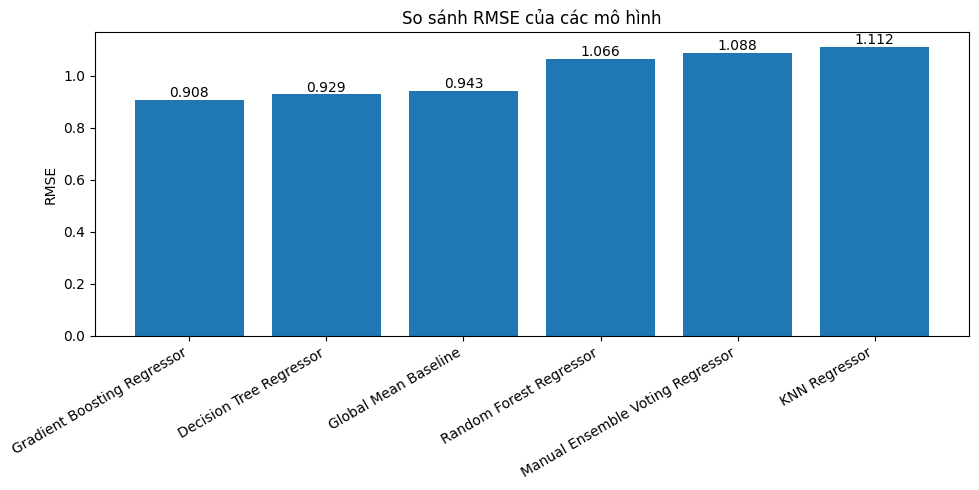

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.bar(
    bang_ket_qua_sap_xep["Model"],
    bang_ket_qua_sap_xep["RMSE"]
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("So sánh RMSE của các mô hình")

for i, v in enumerate(bang_ket_qua_sap_xep["RMSE"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()


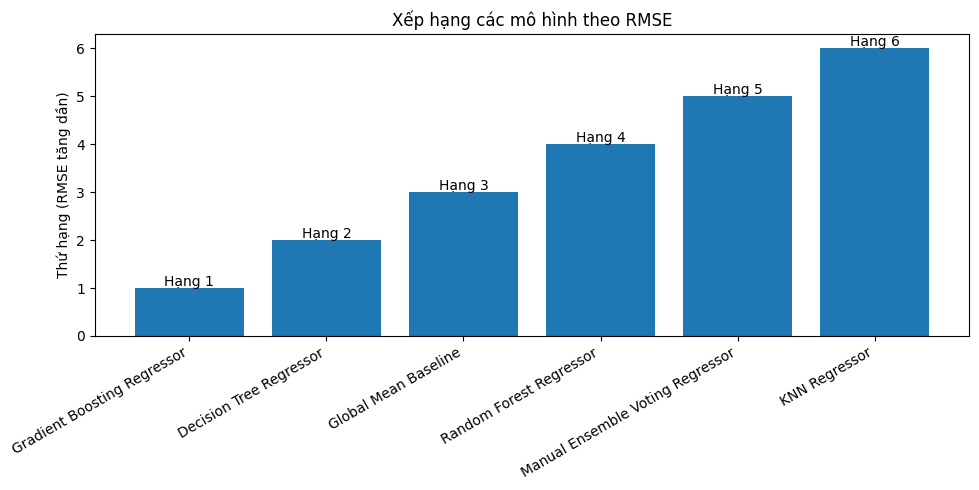

In [6]:
import matplotlib.pyplot as plt
bang_ket_qua_sap_xep = bang_ket_qua_sap_xep.reset_index(drop=True)
bang_ket_qua_sap_xep["Thu_hang"] = bang_ket_qua_sap_xep.index + 1

plt.figure(figsize=(10, 5))

plt.bar(
    bang_ket_qua_sap_xep["Model"],
    bang_ket_qua_sap_xep["Thu_hang"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Thứ hạng (RMSE tăng dần)")
plt.title("Xếp hạng các mô hình theo RMSE")

for i, v in enumerate(bang_ket_qua_sap_xep["Thu_hang"]):
    plt.text(i, v + 0.05, f"Hạng {v}", ha="center")

plt.tight_layout()
plt.show()